# P-value thinning on UK Biobank summary statistics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Tuning parameter exploration

1. Load a small subset of `bmi_summary_stats.csv` (a genome-wide association
   study of BMI; one row per SNP, with its association p-value).
2. Identify SNPs genome-wide significant by the standard threshold
   $5 \times 10^{-8}$.

In [2]:
df = pd.read_csv("../data/bmi_summary_stats.csv", nrows=100_000)
df.head()

,snp,p_value,effect_sign
0,rs10399793,0.770,1.0
1,rs2462492,0.540,1.0
2,rs114608975,0.210,1.0
3,rs6702460,0.230,1.0
4,rs8179466,0.072,-1.0


In [3]:
epsilon = 0.5
p = df["p_value"].to_numpy()

rng = np.random.default_rng(0)

U = rng.uniform(0, 1, size=len(p))
C = rng.binomial(1, epsilon, size=len(p))

p1 = p**epsilon * (C + (1 - C) * U)
p2 = p ** (1 - epsilon) * ((1 - C) + C * U)

df["p1"] = p1
df["p2"] = p2
df[["snp", "p_value", "p1", "p2"]].head()

,snp,p_value,p1,p2
0,rs10399793,0.770,0.877497,0.558932
1,rs2462492,0.540,0.198252,0.734847
2,rs114608975,0.210,0.458257,0.018776
3,rs6702460,0.230,0.479583,0.007926
4,rs8179466,0.072,0.268327,0.218223


In [4]:
# Stringent threshold
threshold = 5e-8

significant_snps = set(df.loc[df["p_value"] < threshold, "snp"])
print(f"{len(significant_snps)} of {len(df)} SNPs are significant (p < {threshold:g})")

significant_snps_p1 = set(df.loc[df["p1"] < threshold**epsilon, "snp"])
print(f"{len(significant_snps_p1)} of {len(df)} SNPs are significant by p1 (p1 < {threshold**epsilon:g})")

shared = significant_snps_p1 & significant_snps
tpr = len(shared) / len(significant_snps_p1) if significant_snps_p1 else float("nan")
print(f"{len(shared)} of {len(significant_snps_p1)} p1-significant SNPs are also raw-p significant")
print(f"TPR: {tpr:.3f}")

543 of 100000 SNPs are significant (p < 5e-08)
700 of 100000 SNPs are significant by p1 (p1 < 0.000223607)
543 of 700 p1-significant SNPs are also raw-p significant
TPR: 0.776


## Threshold examination

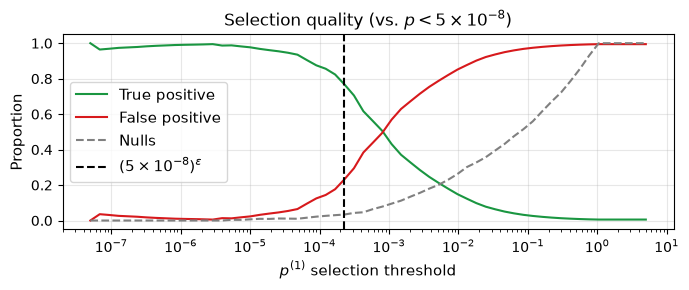

In [16]:
thresholds = 5 * np.logspace(-8, 0, 60)
ground_truth = df["p_value"] < threshold
n_pos, n_neg = ground_truth.sum(), (~ground_truth).sum()

# uniform 
nulls = rng.uniform(size=len(p))

tpr_curve, fpr_curve, null_fdr = [], [], []
for t in thresholds:
    predicted = df["p1"] < t
    tp = (predicted & ground_truth).sum()
    fp = (predicted & ~ground_truth).sum()

    # Proportions
    tpr_curve.append(tp / predicted.sum())
    fpr_curve.append(fp / predicted.sum())
    null_fdr.append(np.min([(nulls < t).sum() / predicted.sum(), 1]))

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(thresholds, tpr_curve, label="True positive", color="#1a9641")
ax.plot(thresholds, fpr_curve, label="False positive", color="#d7191c")
ax.plot(thresholds, null_fdr, label="Nulls", ls='--', color="grey")
ax.axvline(
    (5e-8) ** epsilon, color="black", linestyle="--",
    label=r"$(5\times10^{-8})^\epsilon$"
)
ax.set_xscale("log")
# ax.set_yscale('log')
ax.set_xlabel(r"$p^{(1)}$ selection threshold", fontsize=11)
ax.set_ylabel("Proportion", fontsize=11)
ax.set_title(r"Selection quality (vs. $p < 5\times10^{-8}$)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/ukb_selection_prop.png", dpi=300, bbox_inches='tight')
plt.show()

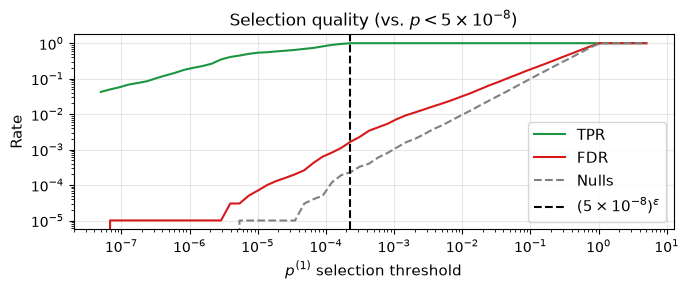

In [17]:
thresholds = 5 * np.logspace(-8, 0, 60)
ground_truth = df["p_value"] < threshold
n_pos, n_neg = ground_truth.sum(), (~ground_truth).sum()

# uniform 
nulls = rng.uniform(size=len(p))

tpr_curve, fpr_curve, null_fdr = [], [], []
for t in thresholds:
    predicted = df["p1"] < t
    tp = (predicted & ground_truth).sum()
    fp = (predicted & ~ground_truth).sum()
    
    # Rates
    tpr_curve.append(tp / n_pos)
    fpr_curve.append(fp / n_neg)
    null_fdr.append((nulls < t).mean())

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(thresholds, tpr_curve, label="TPR", color="#1a9641")
ax.plot(thresholds, fpr_curve, label="FDR", color="#d7191c")
ax.plot(thresholds, null_fdr, label="Nulls", ls='--', color="grey")
ax.axvline(
    (5e-8) ** epsilon, color="black", linestyle="--",
    label=r"$(5\times10^{-8})^\epsilon$"
)
# ax.axvline(
#     22e-8, color="grey", linestyle="--",
#     label=r"$2.2\times10^{-7}$"
# )
ax.set_xscale("log")
ax.set_yscale('log')
ax.set_xlabel(r"$p^{(1)}$ selection threshold", fontsize=11)
ax.set_ylabel("Rate", fontsize=11)
ax.set_title(r"Selection quality (vs. $p < 5\times10^{-8}$)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/ukb/ukb_selection_ratios.png", dpi=300, bbox_inches='tight')
plt.show()

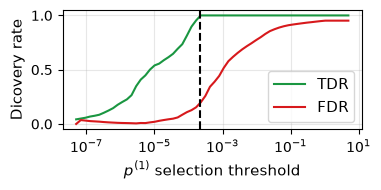

In [5]:
# For paper 
epsilon = 0.5
thresholds = 5 * np.logspace(-8, 0, 60)
alpha = 0.05
oracle = df["p_value"] < threshold
# uniform 
nulls = rng.uniform(size=len(p))

tdr, fdr = [], []
for t in thresholds:
    discovered = (df["p1"] < t) & (df["p2"] < alpha)
    tdr.append((discovered & oracle).sum() / oracle.sum())
    fdr.append((discovered & (~oracle)).sum() / discovered.sum())


fig, ax = plt.subplots(figsize=(4, 2))
ax.plot(thresholds, tdr, label="TDR", color="#1a9641")
ax.plot(thresholds, fdr, label="FDR", color="#d7191c")
# ax.plot(thresholds, null_fdr, label="Nulls", ls='--', color="grey")
ax.axvline(
    (5e-8) ** epsilon, color="black", linestyle="--",
    # label=r"$(5\times10^{-8})^\epsilon$"
)
ax.set_xscale("log")
# ax.set_yscale('log')
ax.set_xlabel(r"$p^{(1)}$ selection threshold", fontsize=11)
ax.set_ylabel("Dicovery rate", fontsize=11)
# ax.set_title(r"Testing quality (vs. $p < 5\times10^{-8}$)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/ukb_threshold_discoveries.png", dpi=300, bbox_inches='tight')
plt.show()

## Epsilon examination

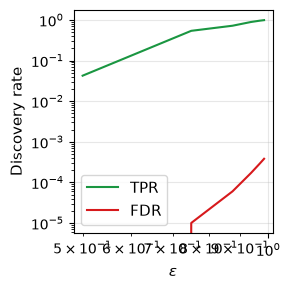

In [19]:
threshold = 5e-8
ground_truth = df["p_value"] < threshold
n_pos, n_neg = ground_truth.sum(), (~ground_truth).sum()

epsilons = np.asarray([1/2, 1 - 1/4, 1 - 1/8, 1 - 1/16, 1 - 1/32, 1 - 1/64])

# uniform 
nulls = rng.uniform(size=len(p))

tpr_curve, fpr_curve, null_fdr = [], [], []
for eps in epsilons:
    # threshold = (5e-8)**eps
    df["p1_e"] = p**eps * (C + (1 - C) * U)
    predicted = df["p1_e"] < threshold
    tp = (predicted & ground_truth).sum()
    fp = (predicted & ~ground_truth).sum()

    # Proportions
    # tpr_curve.append(tp / predicted.sum())
    # fpr_curve.append(fp / predicted.sum())
    # null_fdr.append(np.min([(nulls < threshold).sum() / predicted.sum(), 1]))
    
    # Rates
    tpr_curve.append(tp / n_pos)
    fpr_curve.append(fp / n_neg)
    null_fdr.append((nulls < threshold).mean())

fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(epsilons, tpr_curve, label="TPR", color="#1a9641")
ax.plot(epsilons, fpr_curve, label="FDR", color="#d7191c")
# ax.plot(epsilons, null_fdr, label="Nulls", ls='--', color="grey")
# ax.axvline(
#     (5e-8) ** epsilon, color="black", linestyle="--",
#     label=r"$(5\times10^{-8})^\epsilon$"
# )
ax.set_xscale("log")
ax.set_yscale('log')
ax.set_xlabel(r"$\epsilon$", fontsize=11)
ax.set_ylabel("Discovery rate", fontsize=11)
# ax.set_title(r"Selection quality (vs. $p < 5\times10^{-8}$)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/ukb_selection_epsilon_rate.png", dpi=300, bbox_inches='tight')
plt.show()

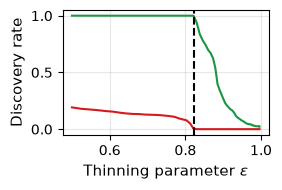

In [16]:
threshold = 5e-8
epsilons = (1 - 2**np.linspace(-8, -1, 100))[::-1]

alpha = 0.05
oracle = df["p_value"] < threshold
# uniform 
nulls = rng.uniform(size=len(p))

tdr, fdr = [], []
for eps in epsilons:
    df["p1_e"] = p**eps * (C + (1 - C) * U)
    df["p2_e"] = p ** (1 - eps) * ((1 - C) + C * U)
    
    t = threshold ** eps

    discovered = (df["p1_e"] <= t) & (df["p2_e"] <= alpha)
    tdr.append((discovered & oracle).sum() / oracle.sum())
    fdr.append((discovered & (~oracle)).sum() / discovered.sum())


fig, ax = plt.subplots(figsize=(3, 2))
ax.plot(epsilons, tdr, label="TDR", color="#1a9641")
ax.plot(epsilons, fdr, label="FDR", color="#d7191c")
ax.axvline(
    1 - np.log(5e-2) / np.log(5e-8), color="black", linestyle="--",
    # label=r"$(5\times10^{-8})^\epsilon$"
)
# ax.set_xscale("log")
# ax.set_yscale('log')
ax.set_xlabel(r"Thinning parameter $\epsilon$", fontsize=11)
ax.set_ylabel("Discovery rate", fontsize=11)
# ax.set_title(r"Testing quality (vs. $p < 5\times10^{-8}$)")
# ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/ukb_epsilon_discoveries.png", dpi=300, bbox_inches='tight')
plt.show()
# 0.8 seems to work well

## Testing/comparison

In [ ]:
from scipy.stats import norm
from scipy import stats
from joblib import Parallel, delayed
from pthin import pthin, pcarve_estimate, truncgauss_estimate

# Load remaining data
N_SUBSET = 100_000
df_pipeline = pd.read_csv(
    "../data/t2d_summary_stats.csv", skiprows=range(1, 10^5 + 1), nrows=N_SUBSET
)
df_pipeline.head()

In [10]:
# Recover the (signed) Z-score from the two-sided p-value and effect sign
Z = df_pipeline["effect_sign"].to_numpy() * norm.isf(df_pipeline["p_value"].to_numpy() / 2)

In [11]:
# (3) Data-thin the Z-scores (Gaussian thinning) into independent train/test
# splits: Z_train, Z_test ~ N(mu/sqrt2, 1), independent given mu. Train is
# used for selection + estimation below; test is an independent, unbiased
# stand-in for the (otherwise unknown, in real data) true effect, used only
# to evaluate MSE.
rng = np.random.default_rng(1)
W = rng.normal(0, 1, size=len(Z))
Z_train = (Z + W) / np.sqrt(2)
Z_test = (Z - W) / np.sqrt(2)

# Two-sided p-value of the train split, against theta0=0
p_train = norm.sf(np.abs(Z_train))

In [ ]:
# (4) P-thinning (epsilon=0.8): select where p1 < (5e-8)^epsilon. For each
# selected SNP, branch on the held-out p2_train's significance:
#   - p2_train < 0.05 (confident of direction): estimate one-sided, in the
#     direction of Z_train (reflect via |Z_train| then reattach the sign)
#     -- accepting the risk of a Type III (wrong-sign) error. b=threshold_
#     pthin is exactly right here since p_train = norm.sf(|Z_train|) =
#     norm.sf(Z_train) once reflected to Z_train>=0.
#   - otherwise: estimate via the folded-normal (two-sided) conditional
#     likelihood, since we can't trust the sign. theta is constrained >=0
#     (a magnitude estimate), since Folded-Normal(theta,1) ==
#     Folded-Normal(-theta,1) makes theta unidentifiable past its sign
#     otherwise. The selection region's b is rescaled by 2**epsilon
#     relative to the one-sided case: the folded family's own theta0=0
#     survival function is foldnorm(c=0).sf(t) = 2*norm.sf(t) = 2*p_train
#     (verified numerically), and pthin(c*p, eps) == c**eps * pthin(p, eps)
#     for the same underlying randomization (pthin's p1 is a pure power of
#     p times a p-independent random factor) -- so the *same* selection
#     event p1_train < threshold_pthin, reexpressed on the folded p-value
#     scale, is p1_folded < threshold_pthin * 2**epsilon.
# MSE against the held-out test Z-score in both cases -- the folded
# branch's magnitude estimate is signed by Z_train too, for a metric
# comparable across both branches (an explicit choice: an alternative
# would leave it unsigned and compare to |Z_test| instead).
epsilon = 0.8
alpha = 5e-8

p1_train, p2_train = pthin(p_train, epsilon=epsilon, rng=rng)
threshold_pthin = alpha**epsilon
selected_pthin = p1_train < threshold_pthin

folded_density = lambda theta: stats.foldnorm(c=theta, loc=0, scale=1)
threshold_pthin_folded = threshold_pthin * (2**epsilon)


def onesided_combined(z):
    x = abs(z)
    mle = pcarve_estimate(
        x, 0.0, a=0.0, b=threshold_pthin, epsilon=epsilon, estimator="mle",
        input_type="statistic", epsabs=1e-4, epsrel=1e-4, limit=50,
    )
    mean = pcarve_estimate(
        x, 0.0, a=0.0, b=threshold_pthin, epsilon=epsilon, estimator="mean",
        input_type="statistic", epsabs=1e-4, epsrel=1e-4, limit=50, n_points=41,
    )
    return np.sign(z) * (mle + mean) / 2


def folded_combined(z):
    x = abs(z)
    mle = pcarve_estimate(
        x, 0.0, a=0.0, b=threshold_pthin_folded, epsilon=epsilon, density=folded_density,
        estimator="mle", input_type="statistic", epsabs=1e-4, epsrel=1e-4, limit=50,
        theta_min=0.0,
    )
    mean = pcarve_estimate(
        x, 0.0, a=0.0, b=threshold_pthin_folded, epsilon=epsilon, density=folded_density,
        estimator="mean", input_type="statistic", epsabs=1e-4, epsrel=1e-4, limit=50,
        n_points=41, theta_min=0.0,
    )
    return np.sign(z) * (mle + mean) / 2


def pcarve_directional(z, p2):
    return onesided_combined(z) if p2 < 0.05 else folded_combined(z)


pthin_estimates = np.array(
    Parallel(n_jobs=-1)(
        delayed(pcarve_directional)(z, p2)
        for z, p2 in zip(Z_train[selected_pthin], p2_train[selected_pthin])
    )
)
mse_pthin = np.mean((pthin_estimates - Z_test[selected_pthin]) ** 2)
print(f"p-thinning: {selected_pthin.sum()} selected, MSE = {mse_pthin:.3f}")

In [13]:
# (5) Naive: select where p_train < 5e-8 (no thinning), estimate with the
# (uncorrected) train Z-score itself -- classic double dipping.
selected_naive = p_train < alpha
mse_naive = np.mean((Z_train[selected_naive] - Z_test[selected_naive]) ** 2)
print(f"naive: {selected_naive.sum()} selected, MSE = {mse_naive:.3f}")

naive: 34 selected, MSE = 4.757


In [ ]:
# (6) Conditional (truncated Gaussian): select where Z_train clears the
# same 5e-8 threshold directly, then estimate via truncgauss_estimate's
# combined estimator.
c_alpha = norm.isf(alpha)
selected_csi = Z_train >= c_alpha


def truncgauss_combined(x):
    mle = truncgauss_estimate(x, c=c_alpha, estimator="mle")
    mean = truncgauss_estimate(x, c=c_alpha, estimator="mean")
    return (mle + mean) / 2


csi_estimates = np.array(
    Parallel(n_jobs=-1)(delayed(truncgauss_combined)(x) for x in Z_train[selected_csi])
)
mse_csi = np.mean((csi_estimates - Z_test[selected_csi]) ** 2)
print(f"conditional: {selected_csi.sum()} selected, MSE = {mse_csi:.3f}")

/Users/rflperry/Documents/UW/daniela_ra/pval_thinning/pthin/estimate.py:234: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  total, _ = quad(likelihood, -np.inf, np.inf, limit=200)


conditional: 26 selected, MSE = 2595421673.991


/Users/rflperry/Documents/UW/daniela_ra/pval_thinning/pthin/estimate.py:235: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  numerator, _ = quad(lambda theta: theta * likelihood(theta), -np.inf, np.inf, limit=200)


In [15]:
pd.DataFrame({
    "method": ["naive", "p-thinning", "conditional"],
    "n_selected": [selected_naive.sum(), selected_pthin.sum(), selected_csi.sum()],
    "mse": [mse_naive, mse_pthin, mse_csi],
})

,method,n_selected,mse
0,naive,34,4.757217e+00
1,p-thinning,38,3.997928e+00
2,conditional,26,2.595422e+09
